In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
import jax
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer

In [14]:
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator

In [15]:
import equinox as eqx
import jax.tree_util as jtu
import optax

## Importing the dataset (CIFAR)

In [16]:
from darnax.datasets.classification.cifar10 import Cifar10

data = Cifar10(
    batch_size=32,
    linear_projection=None,
    label_mode="pm1",
    x_transform="identity",
)

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)

data.build(key=data_key)

Array([2566685366, 2716172981], dtype=uint32)

In [17]:
# In order to do something:
# first we take a batch of data and we standardize it

x, y = next(iter(data))
print(f"Data shape: x={x.shape}, y={y.shape}")
print(f"Expected: x=(batch, 32, 32, 3), got x={x.shape}")

# If flattened, reshape it back
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
    print(f"Reshaped x to: {x.shape}")

x = (x - x.mean()) / x.std()

Data shape: x=(32, 3072), y=(32, 10)
Expected: x=(batch, 32, 32, 3), got x=(32, 3072)
Reshaped x to: (32, 32, 32, 3)


## Build model 

In [18]:
def build_conv_model(
    seed: int,
    in_channels: int = 3,
    spatial_size: int = 32,
    n_channels: int = 64,
    num_labels: int = 10,
    input_kernel_size: int = 7,
    recur_kernel_size: int = 7,
    threshold_conv: float = 1.7,
    threshold_fc: float = 1.7,
    threshold_out: float = 1.7,
    threshold_back: float = 0.0,
    j_d_conv: float = 0.9,
    j_d_fc: float = 0.9,
    strength_in: float = 1.0,
    strength_pool: float = 1.0,
    strength_unpool: float = 1.0,
    strength_wout: float = 1.0,
    strength_wback: float = 1.0,
    lr_conv: float = 1.0,
    weight_decay_conv: float = 0.0,
    mask_prob: float = 0.0,
    field_momentum: float = 0.0
) -> tuple[SequentialState, SequentialOrchestrator]:

    keys = jax.random.split(jax.random.key(seed), 5)

    S = spatial_size

    layer_map = LayerMap.from_dict({
        1: {
            0: Conv2D(
                in_channels=in_channels,
                out_channels=n_channels,
                kernel_size=input_kernel_size,
                threshold=threshold_conv,
                strength=strength_in,
                key=keys[0],
                padding_mode="constant",
            ),
            1: Conv2DRecurrentDiscrete(
                channels=n_channels,
                kernel_size=recur_kernel_size,
                groups=n_channels,
                j_d=j_d_conv,
                threshold=threshold_conv,
                padding_mode="constant",
                key=keys[1],
                lr=lr_conv,
                weight_decay=weight_decay_conv,
            ),
            2: GlobalUnpooling(strength=strength_unpool, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=strength_pool, axis=(1, 2)),
            2: RecurrentDiscrete(
                features=n_channels,
                j_d=j_d_fc,
                threshold=threshold_fc,
                key=keys[2],
            ),
            3: FrozenRescaledFullyConnected(
                in_features=num_labels,
                out_features=n_channels,
                strength=strength_wback,
                threshold=threshold_back,
                key=keys[3],
            ),
        },
        3: {
            2: FullyConnected(
                in_features=n_channels,
                out_features=num_labels,
                strength=strength_wout,
                threshold=threshold_out,
                key=keys[4],
            ),
            3: OutputLayer(),
        },
    })

    state = SequentialState([
        (S, S, in_channels),
        (S, S, n_channels),
        (n_channels,),
        (num_labels,),
    ])
    orchestrator = SequentialOrchestrator(layers=layer_map, field_momentum=field_momentum, mask_prob=mask_prob)

    return state, orchestrator

## Run dynamics 

In [19]:
def run_dynamics(
    orchestrator: SequentialOrchestrator,
    state: SequentialState,
    rng,
    n_warmup: int = 1,
    n_clamped: int = 5,
    n_free: int = 5,
) -> tuple[SequentialState, list[SequentialState]]:

    history = []

    for _ in range(n_warmup):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)

    for _ in range(n_clamped):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="all")
        history.append(state)

    for _ in range(n_free):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)

    return state, history

## Weight update

In [20]:
def build_optimizer(
    orchestrator: SequentialOrchestrator,
    lr_w_in: float = 0.1,
    lr_j_conv: float = 0.05,
    lr_j_fc: float = 0.05,
    lr_w_out: float = 0.1,
    trainable_overrides: dict[tuple[int, int], str] | None = None,
) -> tuple[optax.GradientTransformation, optax.OptState]:

    if trainable_overrides is None:
        trainable_overrides = {
            (1, 0): "w_in",
            (1, 1): "j_conv",
            (2, 2): "j_fc",
            (3, 2): "w_out",
        }

    # Build label tree: every leaf starts as "default" (frozen, lr=0)
    params, _ = eqx.partition(orchestrator, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)

    def like(tree, value: str):
        return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

    for (i, j), label in trainable_overrides.items():
        labels = eqx.tree_at(
            lambda m, _i=i, _j=j: m.lmap[_i][_j],
            labels,
            replace=like(params.lmap[i][j], label),
        )

    # Map each label → its SGD optimizer
    lr_map = {
        "w_in":  lr_w_in,
        "j_conv": lr_j_conv,
        "j_fc":  lr_j_fc,
        "w_out": lr_w_out,
    }
    transforms = {"default": optax.sgd(learning_rate=0.0)}
    transforms.update({lbl: optax.sgd(learning_rate=lr) for lbl, lr in lr_map.items()})

    optimizer = optax.multi_transform(transforms, labels)
    opt_state = optimizer.init(eqx.filter(orchestrator, eqx.is_inexact_array))

    return optimizer, opt_state

In [21]:
def apply_update(
    orchestrator: SequentialOrchestrator,
    state: SequentialState,
    rng,
    optimizer: optax.GradientTransformation,
    opt_state: optax.OptState,
) -> tuple[SequentialOrchestrator, optax.OptState]:
    """Compute the backward (Hebbian) grads and apply one weight update.

    Parameters
    ----------
    orchestrator:
        Current model.
    state:
        The ``SequentialState`` **after** dynamics have converged
        (i.e. the output of ``run_dynamics``).
    rng:
        A JAX PRNG key.
    optimizer:
        The optax optimizer returned by ``build_optimizer``.
    opt_state:
        Current optimizer state.

    Returns
    -------
    new_orchestrator:
        Updated model with new weights.
    new_opt_state:
        Updated optimizer state.
    """
    # Step 1: backward pass → raw Hebbian grads
    grads = orchestrator.backward(state, rng=rng)

    # Step 2: optimizer scales grads by per-module learning rates
    grads_filtered = eqx.filter(grads, eqx.is_inexact_array)
    params_filtered = eqx.filter(orchestrator, eqx.is_inexact_array)
    updates, new_opt_state = optimizer.update(
        grads_filtered, opt_state, params=params_filtered
    )

    # Step 3: apply updates → new orchestrator
    new_orchestrator = eqx.apply_updates(orchestrator, updates)

    return new_orchestrator, new_opt_state

## Helper

In [22]:
# =====================================================================
# Helper functions — reusable analysis tools
# =====================================================================

def extract_layer(history, layer_idx):
    """Return array (n_steps, batch, *spatial) for a given layer."""
    return [np.array(h.states[layer_idx]) for h in history]


def flatten_layer(activations):
    """Flatten spatial dims → list of (batch, features) arrays."""
    return [a.reshape(a.shape[0], -1) for a in activations]


# --- Cosine similarity matrix ---

def compute_cosine_similarity_matrix(history, layer_idx=1, batch_idx=None):
    """Pairwise cosine similarity between states at all time-step pairs."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    mat = np.zeros((T, T))
    for i in range(T):
        for j in range(i, T):
            if batch_idx is not None:
                sim = cosine_similarity([acts[i][batch_idx]], [acts[j][batch_idx]])[0, 0]
            else:
                sims = [cosine_similarity([acts[i][b]], [acts[j][b]])[0, 0]
                        for b in range(acts[i].shape[0])]
                sim = np.nanmean(sims)
            mat[i, j] = mat[j, i] = sim
    return mat


# --- Neuron flips ---

def compute_neuron_flips(history, layer_idx=1, percentage=True):
    """Fraction (or count) of neurons that flip sign between consecutive steps."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    flips = np.zeros(T - 1)
    for t in range(T - 1):
        diff = (acts[t] != acts[t + 1]).astype(float)  # (batch, features)
        if percentage:
            flips[t] = diff.mean() * 100  # average over batch & features
        else:
            flips[t] = diff.mean(axis=1).sum()  # average per sample, sum over batch
    return flips


# --- Clamped-free distance ---

def clamped_free_distance(history, layer_idx, n_warmup=1, n_clamped=5):
    """Cosine distance between end-of-clamped and end-of-free activations.

    Returns scalar = 1 − mean_batch( cos_sim(clamped_end, free_end) ).
    """
    acts = flatten_layer(extract_layer(history, layer_idx))
    idx_clamped_end = n_warmup + n_clamped - 1
    idx_free_end = len(acts) - 1
    sims = [cosine_similarity([acts[idx_clamped_end][b]], [acts[idx_free_end][b]])[0, 0]
            for b in range(acts[idx_clamped_end].shape[0])]
    return 1.0 - np.nanmean(sims)


# --- W_back overlap ---

def compute_wback_overlap(history, wback_module, layer_idx=2, output_idx=3):
    """Cosine similarity between wback(y) and layer_idx activation at each step."""
    T = len(history)
    overlaps = np.zeros(T)
    for t in range(T):
        output = np.array(history[t].states[output_idx])     # (batch, 10)
        projected = np.array(wback_module(output))            # (batch, N_CH)
        layer_act = np.array(history[t].states[layer_idx])    # (batch, N_CH)
        sims = []
        for b in range(layer_act.shape[0]):
            p, l = projected[b], layer_act[b]
            norm = np.linalg.norm(p) * np.linalg.norm(l) + 1e-8
            sims.append(np.dot(p, l) / norm)
        overlaps[t] = np.mean(sims)
    return overlaps


# --- Free-phase accuracy + output label alignment ---

def compute_free_metrics(orchestrator, state_final, y_true, rng):
    """Accuracy and output label alignment after the free phase via predict().
    """
    rng, pred_rng = jax.random.split(rng)
    pred_state, _ = orchestrator.predict(state_final, pred_rng)
    predicted  = np.array(pred_state.states[-1])        # (batch, 10)
    y_true_np  = np.array(y_true)                       # (batch, 10), ±1

    true_cls   = np.argmax(y_true_np, axis=-1)          # (batch,)
    pred_cls   = np.argmax(predicted, axis=-1)           # (batch,)
    accuracy   = float(np.mean(pred_cls == true_cls))

    # sign(predicted) ∈ {-1, 0, +1}; element-wise product with ±1 label
    alignment  = float(np.mean(np.sign(predicted) * y_true_np))

    return accuracy, alignment, rng


# Keep old single-return wrapper for backward compatibility with earlier cells
def compute_free_accuracy(orchestrator, state_final, y_true, rng):
    acc, _, rng = compute_free_metrics(orchestrator, state_final, y_true, rng)
    return acc, rng


## Momentum Sweep

Run the multi-update experiment (same batch, 10 updates) for `field_momentum ∈ {0.0, 0.7, 0.95}`.


In [26]:
import jax.numpy as jnp

N_UPDATES  = 10
N_WARMUP, N_CLAMPED, N_FREE = 1, 5, 5
N_STEPS    = N_WARMUP + N_CLAMPED + N_FREE
phase_labels = ["W"] * N_WARMUP + ["C"] * N_CLAMPED + ["F"] * N_FREE

MOMENTUM = [0.0, 0.7, 0.95]


def run_multi_update(momentum, seed=0):
    st, orch = build_conv_model(seed=seed, field_momentum=momentum)
    opt, opt_st = build_optimizer(orch)
    wback = orch.lmap[2][3]

    keys = ["update", "flips_conv_mean", "flips_fc_mean", "cf_dist_conv", "cf_dist_fc",
            "wback_overlap_free", "acc_free", "output_alignment",
            "norm_w_in", "norm_j_conv", "norm_j_fc", "norm_w_out", "histories"]
    metrics = {k: [] for k in keys}

    rng = jax.random.PRNGKey(42)
    for step in range(N_UPDATES + 1):
        s0 = st.init(x, y)
        rng, dyn_rng = jax.random.split(rng)
        state_final, hist = run_dynamics(orch, s0, rng=dyn_rng)

        metrics["update"].append(step)
        metrics["histories"].append(hist)

        flips_c = compute_neuron_flips(hist, layer_idx=1)
        flips_f = compute_neuron_flips(hist, layer_idx=2)
        metrics["flips_conv_mean"].append(flips_c.mean())
        metrics["flips_fc_mean"].append(flips_f.mean())
        metrics["cf_dist_conv"].append(clamped_free_distance(hist, 1, N_WARMUP, N_CLAMPED))
        metrics["cf_dist_fc"].append(clamped_free_distance(hist, 2, N_WARMUP, N_CLAMPED))
        metrics["wback_overlap_free"].append(compute_wback_overlap(hist, wback)[-1])

        acc, alignment, rng = compute_free_metrics(orch, state_final, y, rng)
        metrics["acc_free"].append(acc)
        metrics["output_alignment"].append(alignment)

        for (i, j), key in {(1,0): "norm_w_in",  (1,1): "norm_j_conv",
                             (2,2): "norm_j_fc",  (3,2): "norm_w_out"}.items():
            w = eqx.filter(orch.lmap[i][j], eqx.is_inexact_array)
            flat = jnp.concatenate([l.ravel() for l in jax.tree.leaves(w)])
            metrics[key].append(float(jnp.linalg.norm(flat)))

        print(f"  step {step:2d} | flips conv={flips_c.mean():.1f}% fc={flips_f.mean():.1f}% | "
              f"acc={acc:.1%} align={alignment:+.3f}")

        if step < N_UPDATES:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_st = apply_update(orch, state_final, rng=upd_rng, optimizer=opt, opt_state=opt_st)

    return metrics


all_results = {}
for mo in MOMENTUM:
    print(f"\n=== momentum={mo} ===")
    all_results[mo] = run_multi_update(mo)
print("\nDone.")



=== momentum=0.0 ===
  step  0 | flips conv=2.9% fc=0.9% | acc=12.5% align=-0.044
  step  1 | flips conv=23.9% fc=4.4% | acc=6.2% align=-0.044
  step  2 | flips conv=46.6% fc=9.5% | acc=3.1% align=+0.013
  step  3 | flips conv=60.8% fc=13.2% | acc=12.5% align=+0.094
  step  4 | flips conv=58.1% fc=15.1% | acc=0.0% align=-0.025
  step  5 | flips conv=70.8% fc=18.0% | acc=9.4% align=+0.006
  step  6 | flips conv=84.5% fc=20.2% | acc=0.0% align=+0.069
  step  7 | flips conv=91.3% fc=22.2% | acc=21.9% align=-0.031
  step  8 | flips conv=94.7% fc=22.8% | acc=12.5% align=+0.169
  step  9 | flips conv=96.3% fc=24.0% | acc=18.8% align=+0.144
  step 10 | flips conv=97.8% fc=23.5% | acc=18.8% align=+0.225

=== momentum=0.7 ===
  step  0 | flips conv=1.8% fc=0.5% | acc=12.5% align=-0.069
  step  1 | flips conv=3.6% fc=0.3% | acc=9.4% align=-0.062
  step  2 | flips conv=7.9% fc=0.4% | acc=6.2% align=-0.044
  step  3 | flips conv=12.8% fc=0.5% | acc=18.8% align=+0.069
  step  4 | flips conv=21.6% 

## Plot functions


In [27]:
def plot_cosine_matrices(metrics, title):
    snapshot_steps = [s for s in [0, 1, 3, 5, N_UPDATES] if s <= N_UPDATES]
    fig, axes = plt.subplots(2, len(snapshot_steps), figsize=(4 * len(snapshot_steps), 8))
    for col, step_idx in enumerate(snapshot_steps):
        hist = metrics["histories"][step_idx]
        for row, (lidx, lname) in enumerate([(1, "Conv (1)"), (2, "FC (2)")]):
            ax = axes[row, col]
            cm = compute_cosine_similarity_matrix(hist, layer_idx=lidx)
            im = ax.imshow(cm, cmap="coolwarm", vmin=-0.5, vmax=1, aspect="auto")
            ax.set_title(f"{lname} — update {step_idx}", fontsize=10, fontweight="bold")
            ax.set_xticks(range(N_STEPS)); ax.set_xticklabels(phase_labels, fontsize=6)
            ax.set_yticks(range(N_STEPS)); ax.set_yticklabels(phase_labels, fontsize=6)
            for b in [N_WARMUP - 0.5, N_WARMUP + N_CLAMPED - 0.5]:
                ax.axhline(b, color="white", lw=0.8, ls="--", alpha=0.6)
                ax.axvline(b, color="white", lw=0.8, ls="--", alpha=0.6)
    fig.colorbar(im, ax=axes, label="Cosine similarity", shrink=0.5)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()


def _make_comparison_fig(momentums, ylabel, title, plot_fn, sharey=True):
    """Helper: 1×N figure with one subplot per momentum value."""
    fig, axes = plt.subplots(1, len(momentums), figsize=(6 * len(momentums), 5), sharey=sharey)
    for ax, mo in zip(axes, momentums):
        plot_fn(ax, all_results[mo], mo)
        ax.set_title(f"momentum = {mo}", fontweight="bold")
        ax.set_xlabel("Update step")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()


def plot_all_summary_by_metric(all_results, momentums):
    ups_fn = lambda m: m["update"]

    # 1. Neuron Flips
    def _flips(ax, m, mo):
        ax.plot(ups_fn(m), m["flips_conv_mean"], "o-", label="Conv", linewidth=2)
        ax.plot(ups_fn(m), m["flips_fc_mean"],   "s-", label="FC",   linewidth=2)
        ax.legend()
    _make_comparison_fig(momentums, "Mean % neurons flipped", "Neuron Flips vs Updates", _flips)

    # 2. Clamped-Free Distance
    def _cf(ax, m, mo):
        ax.plot(ups_fn(m), m["cf_dist_conv"], "o-", label="Conv", linewidth=2)
        ax.plot(ups_fn(m), m["cf_dist_fc"],   "s-", label="FC",   linewidth=2)
        ax.legend()
    _make_comparison_fig(momentums, "Cosine distance (1−sim)", "Clamped–Free Distance vs Updates", _cf)

    # 3. Free-Phase Accuracy
    def _acc(ax, m, mo):
        ax.plot(ups_fn(m), [a * 100 for a in m["acc_free"]], "o-", color="green", linewidth=2, label="acc")
        ax.axhline(10, color="gray", lw=1, ls="--", label="Chance (10%)")
        ax.set_ylim(0, 105); ax.legend()
    _make_comparison_fig(momentums, "Accuracy (%)", "Free-Phase Accuracy vs Updates", _acc)

    # 4. W_back Overlap
    def _wback(ax, m, mo):
        ax.plot(ups_fn(m), m["wback_overlap_free"], "o-", color="purple", linewidth=2)
        ax.axhline(0, color="gray", lw=0.5, ls=":")
        ax.set_ylim(-1.05, 1.05)
    _make_comparison_fig(momentums, "Cos sim with W_back(y)", "W_back Overlap vs Updates", _wback)

    # 5. Weight Norms
    def _norms(ax, m, mo):
        for key, lbl, mk in [("norm_w_in","W_in","o-"), ("norm_j_conv","J_conv","s-"),
                              ("norm_j_fc","J_fc","^-"), ("norm_w_out","W_out","D-")]:
            ax.plot(ups_fn(m), m[key], mk, label=lbl, linewidth=2)
        ax.legend(fontsize=8)
    _make_comparison_fig(momentums, "‖W‖ (Frobenius)", "Weight Norms vs Updates", _norms, sharey=False)

    # 6. Output Label Alignment
    def _align(ax, m, mo):
        ax.plot(ups_fn(m), m["output_alignment"], "o-", color="darkorange", linewidth=2)
        ax.axhline(0, color="gray", lw=1, ls="--", label="Chance (0)")
        ax.set_ylim(-1.05, 1.05); ax.legend()
    _make_comparison_fig(momentums, "mean(sign(ŷ)·y) ∈ [−1,+1]", "Output Label Alignment vs Updates", _align)


def plot_flip_profiles_by_momentum(all_results, momentums):
    from matplotlib.cm import viridis
    snapshot_steps = [s for s in [0, 1, 3, 5, N_UPDATES] if s <= N_UPDATES]
    colors = viridis(np.linspace(0, 1, len(snapshot_steps)))

    for lidx, lname in [(1, "Conv (1)"), (2, "FC (2)")]:
        fig, axes = plt.subplots(1, len(momentums), figsize=(6 * len(momentums), 5), sharey=True)
        for ax, mo in zip(axes, momentums):
            for color, step_idx in zip(colors, snapshot_steps):
                flips = compute_neuron_flips(all_results[mo]["histories"][step_idx], layer_idx=lidx)
                xs = np.arange(len(flips))
                ax.plot(xs, flips, "o-", color=color, label=f"update {step_idx}", linewidth=1.5, markersize=4)
            ax.set_title(f"momentum = {mo}", fontweight="bold")
            ax.set_xlabel("Step transition")
            ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
            ax.set_xticks(xs)
            ax.set_xticklabels([f"{phase_labels[t]}→{phase_labels[t+1]}" for t in range(len(flips))],
                               rotation=45, fontsize=7)
        axes[0].set_ylabel("% neurons flipped")
        fig.suptitle(f"Neuron Flip Profiles — {lname}", fontsize=14, fontweight="bold")
        plt.tight_layout(); plt.show()


print("Plot functions defined ✓")


Plot functions defined ✓


## Results


/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_80220/4177425250.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


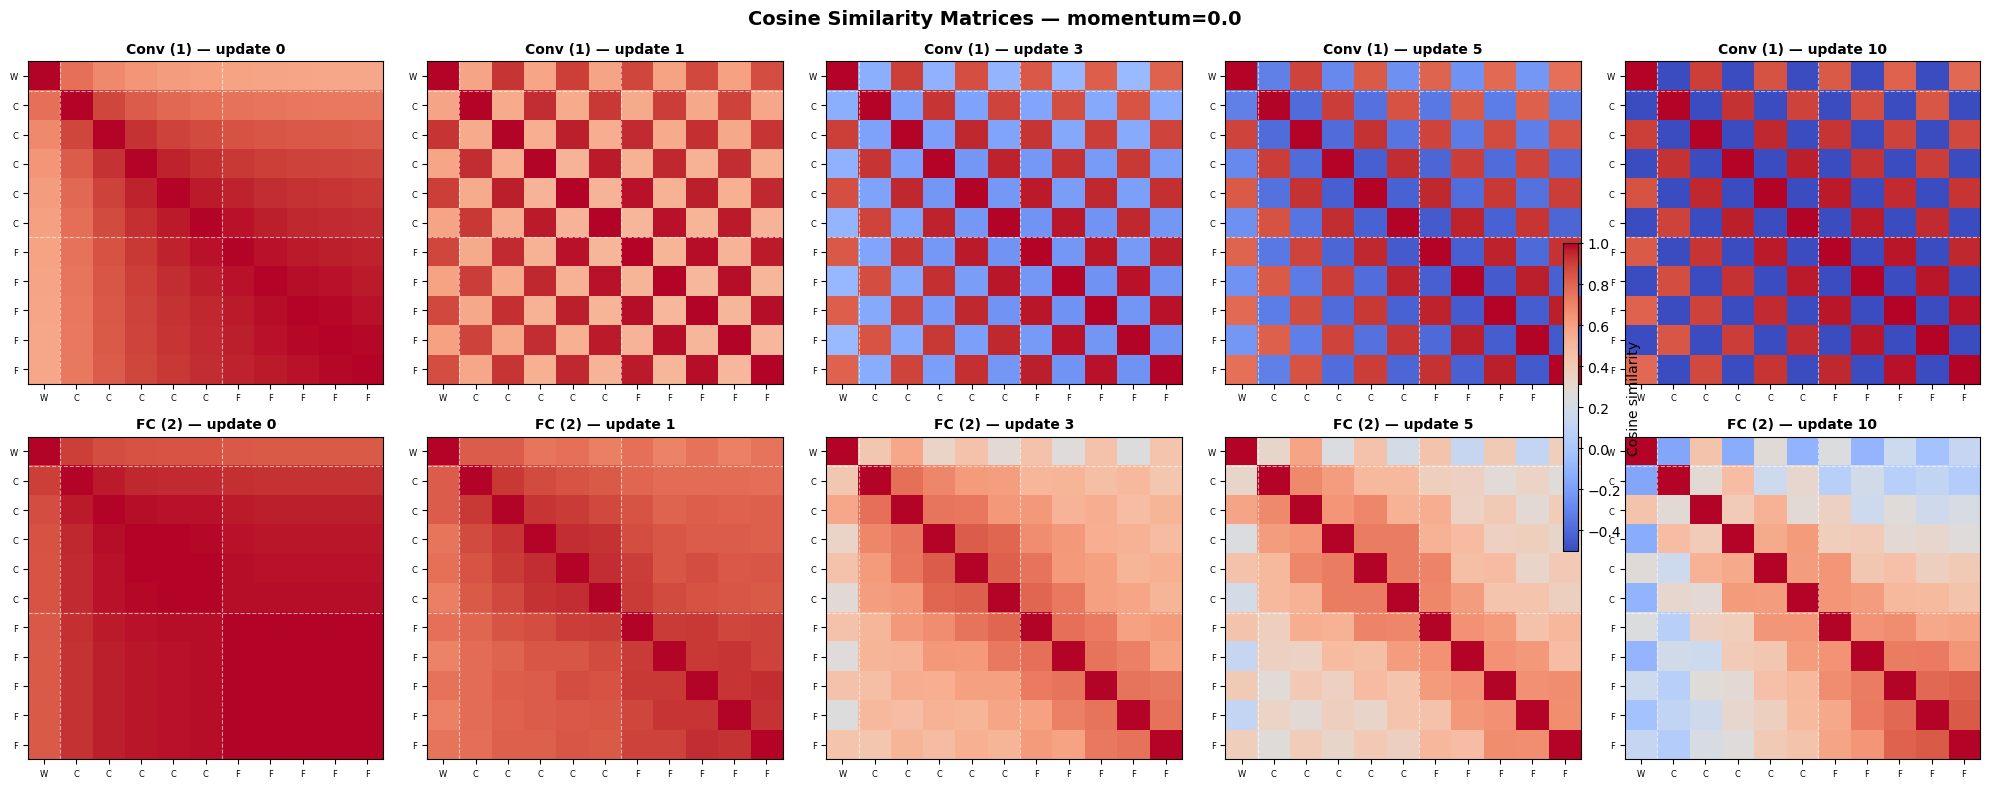

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_80220/4177425250.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


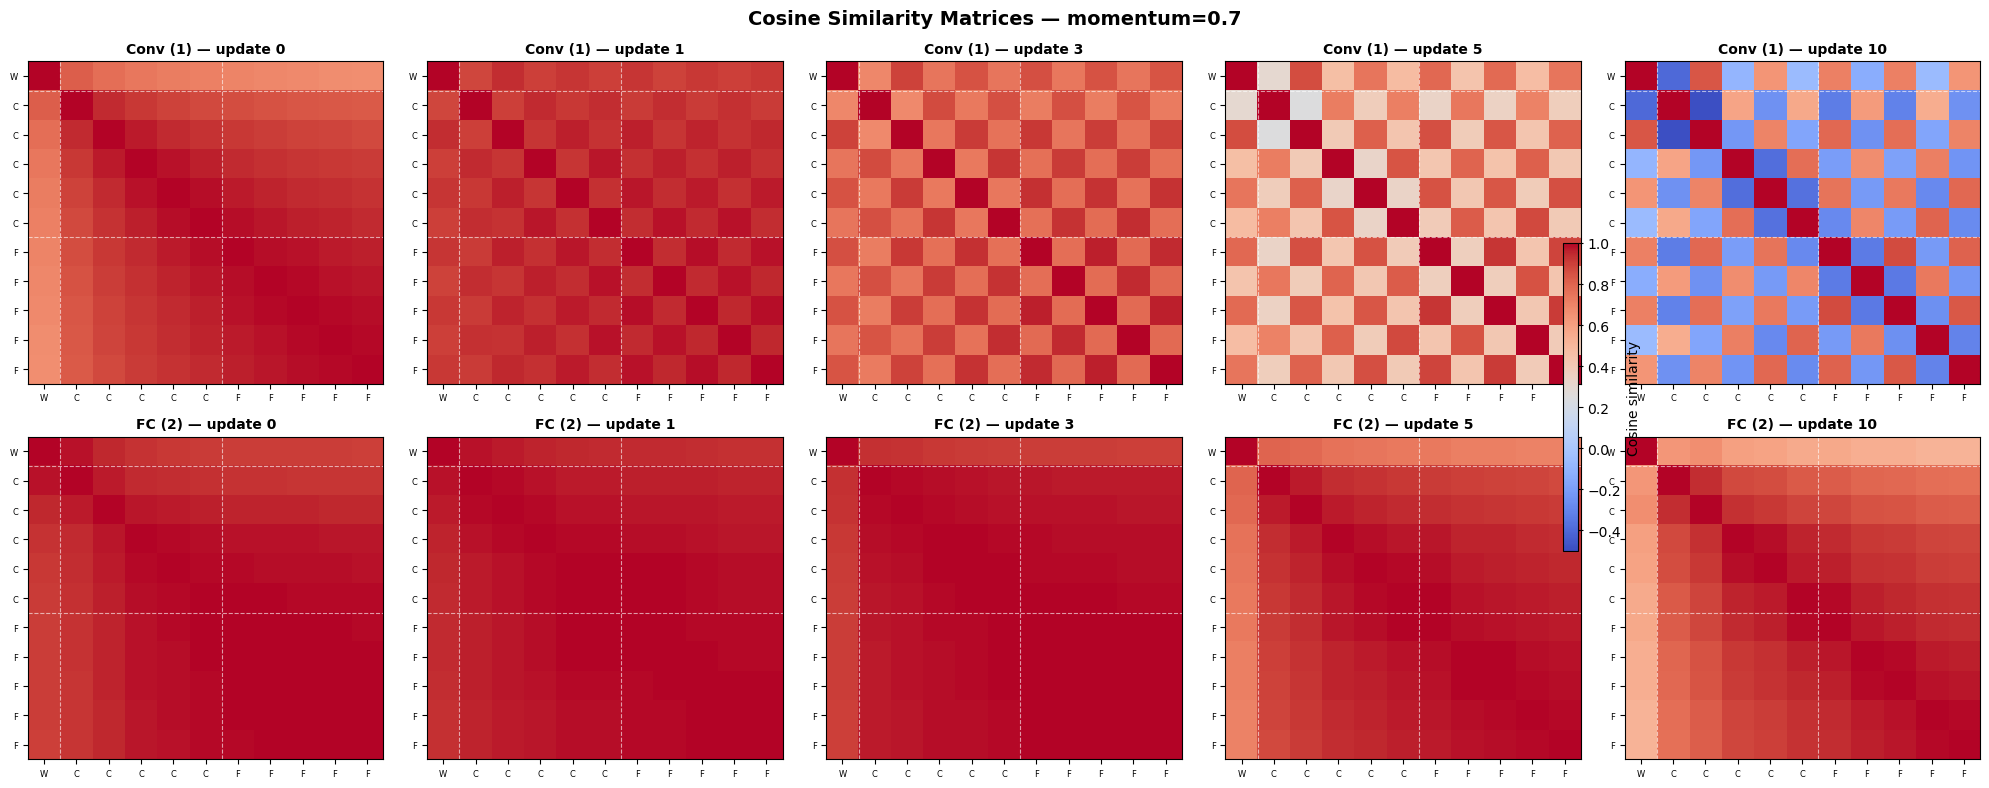

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_80220/4177425250.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


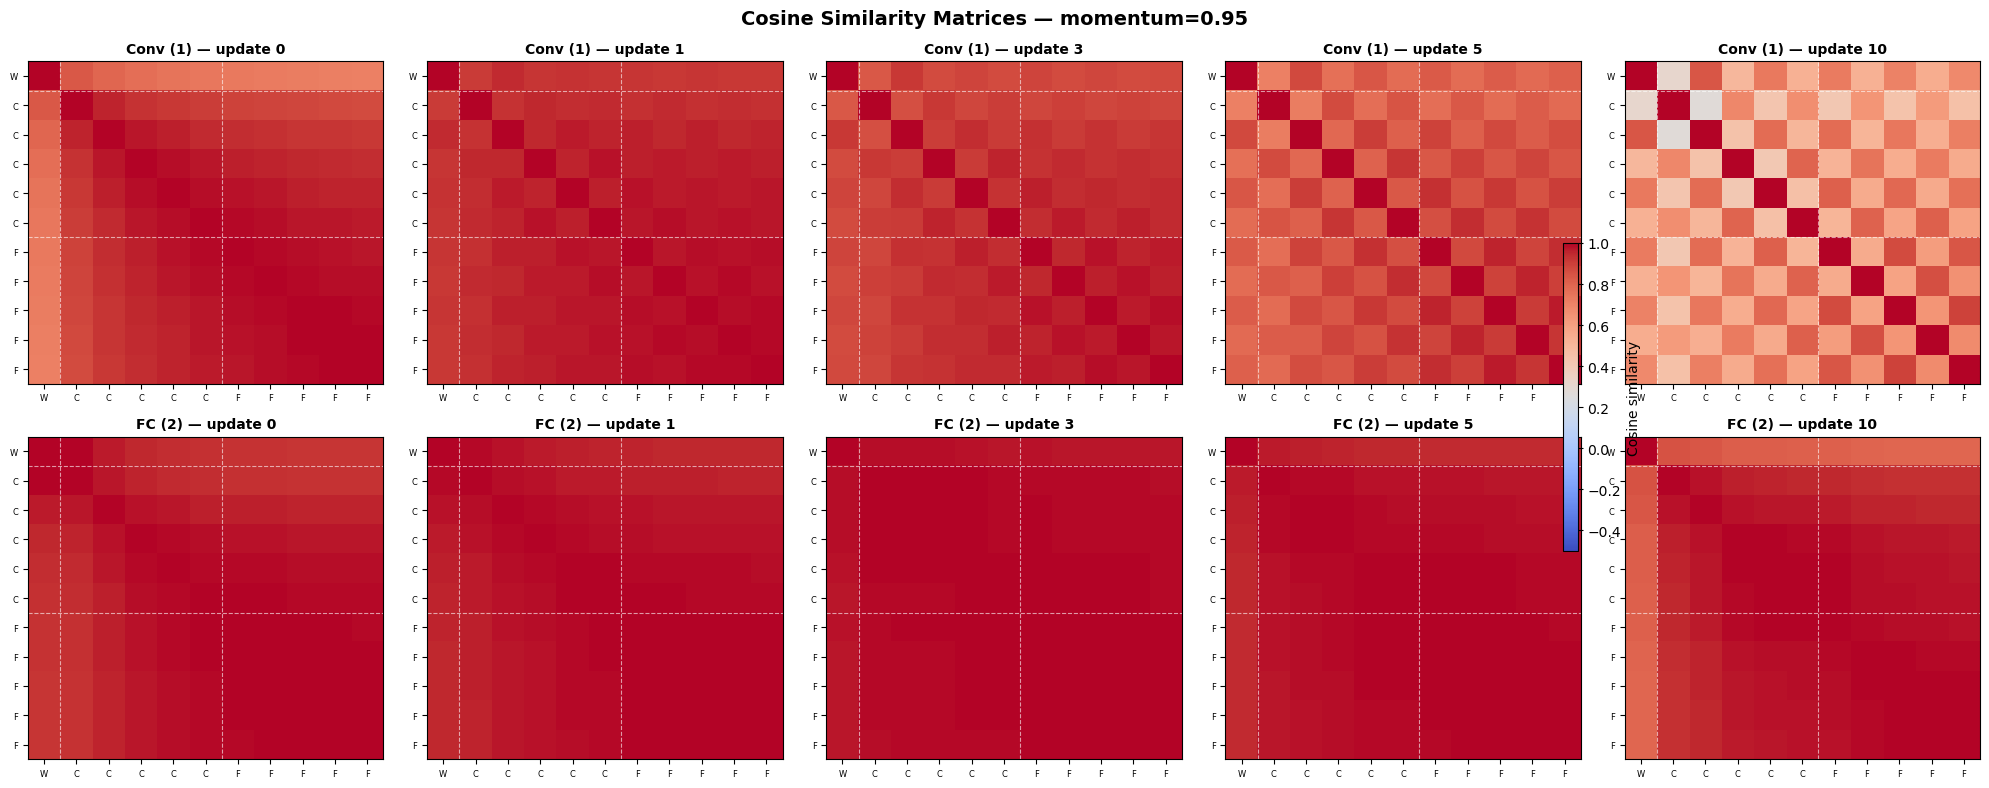

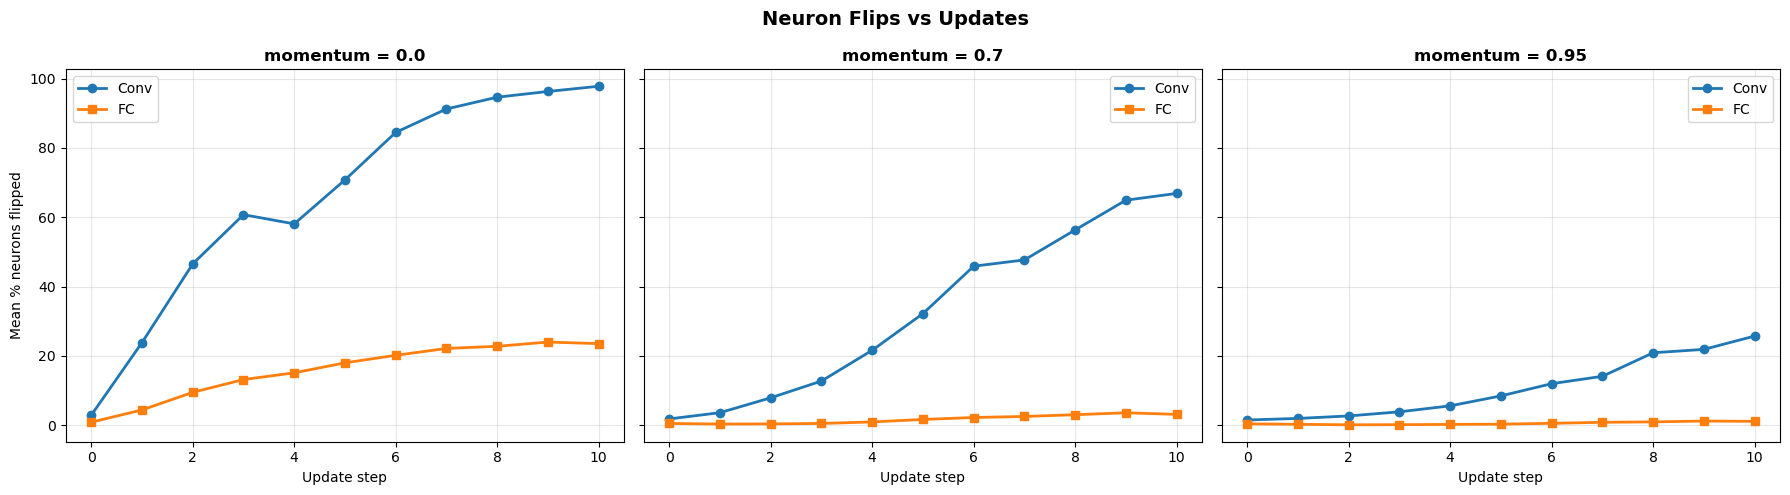

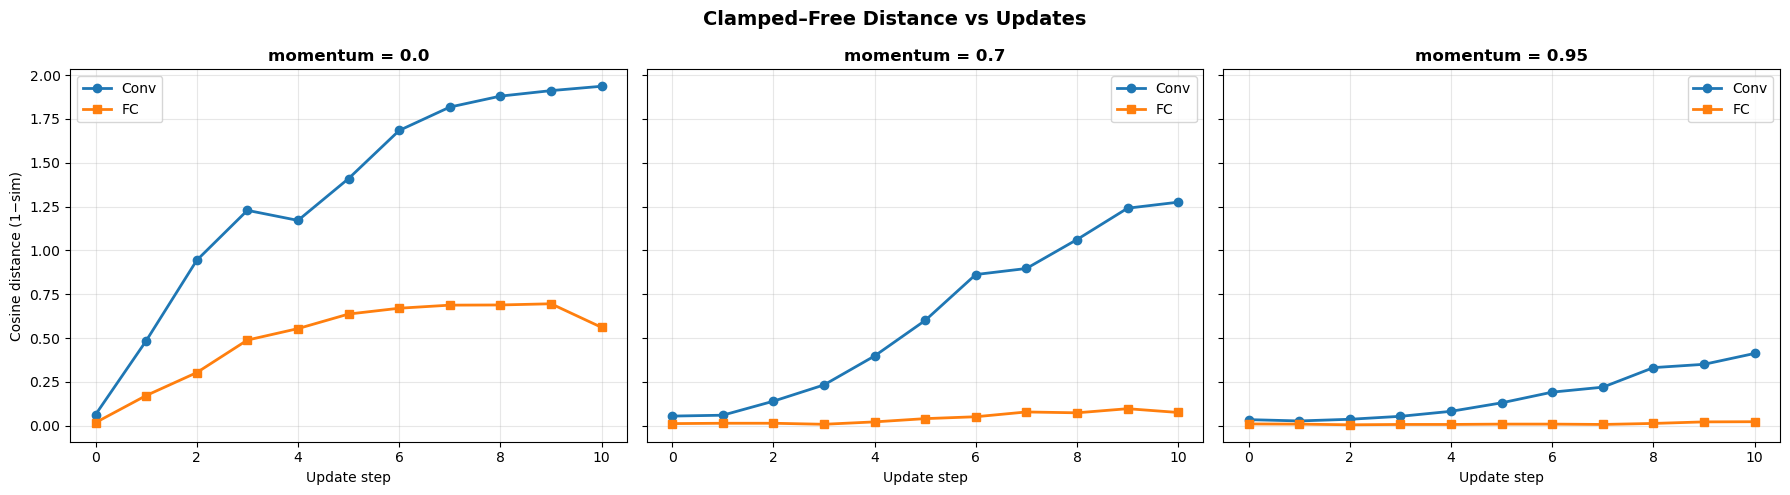

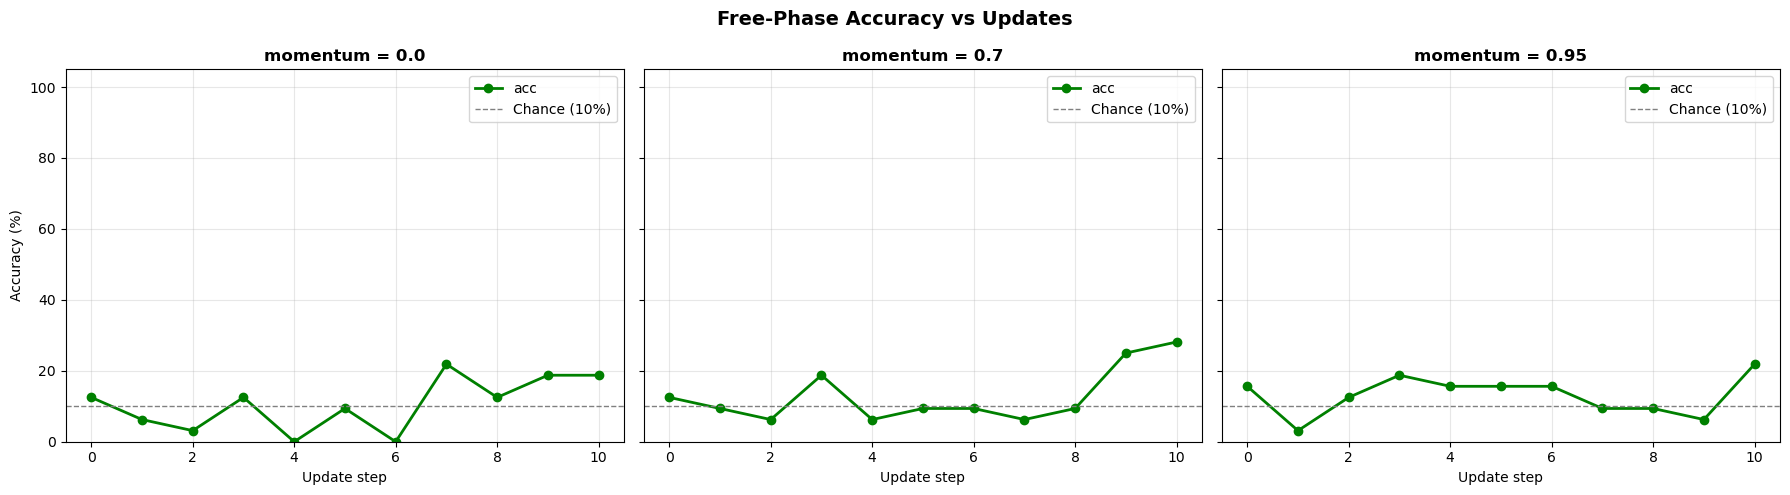

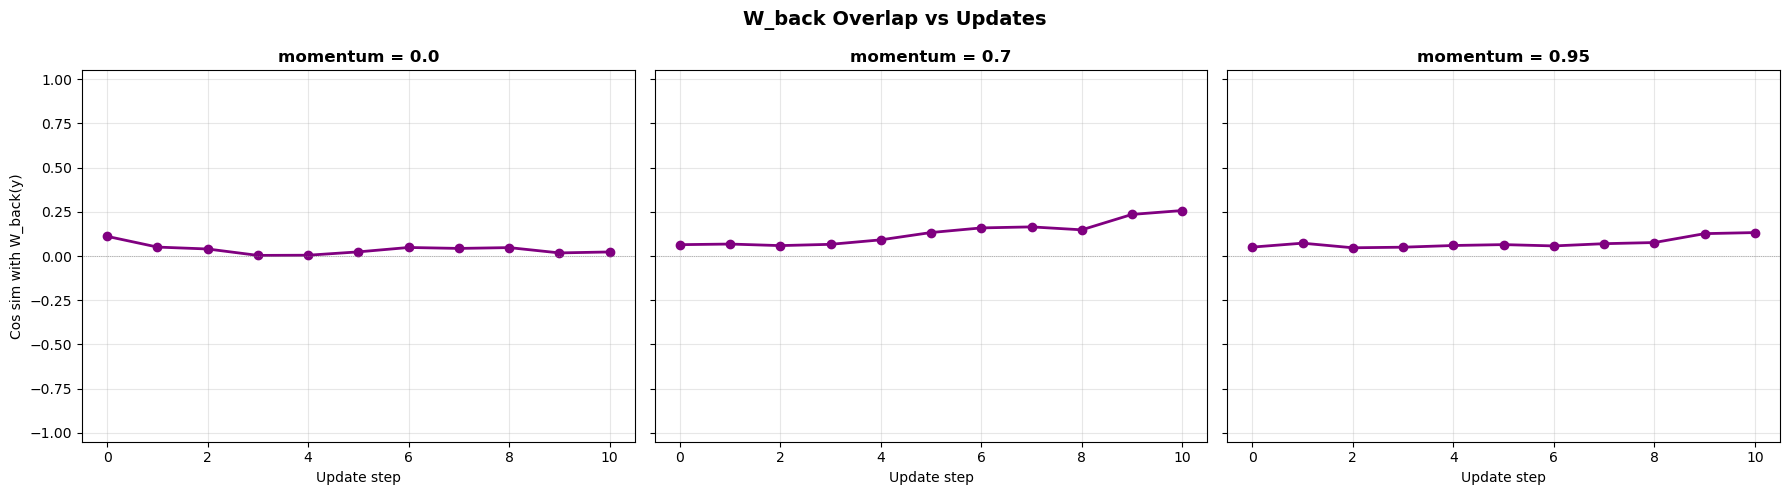

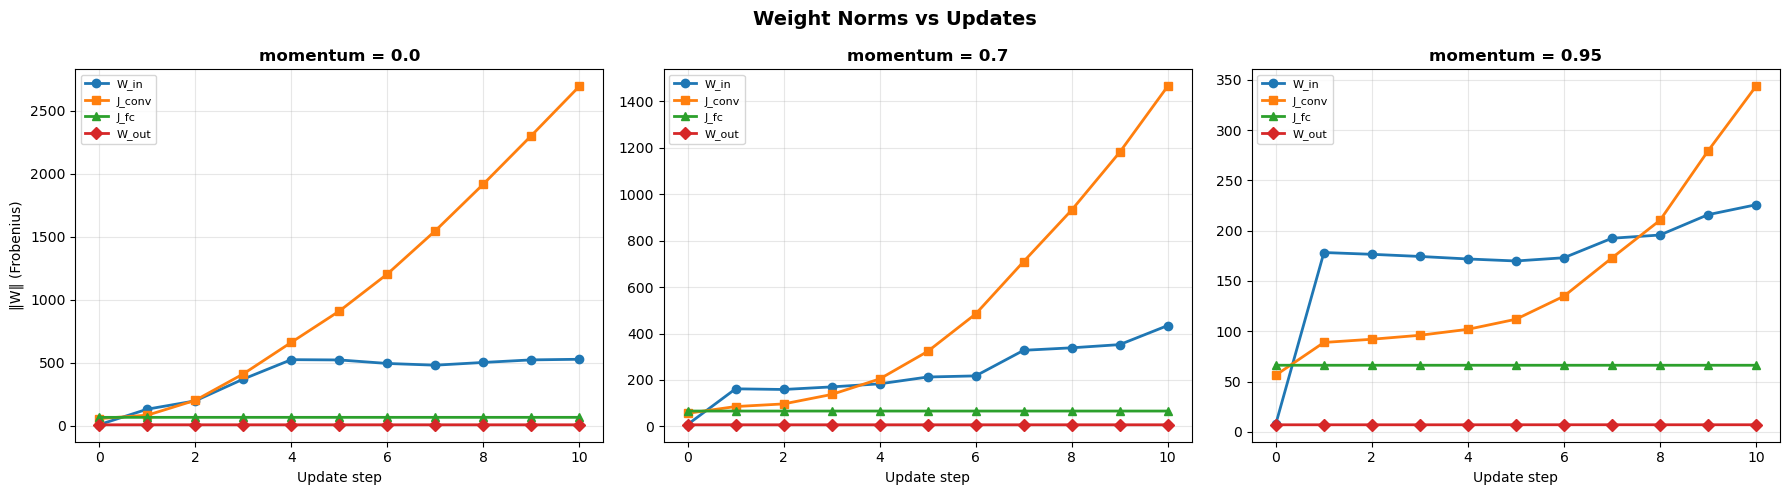

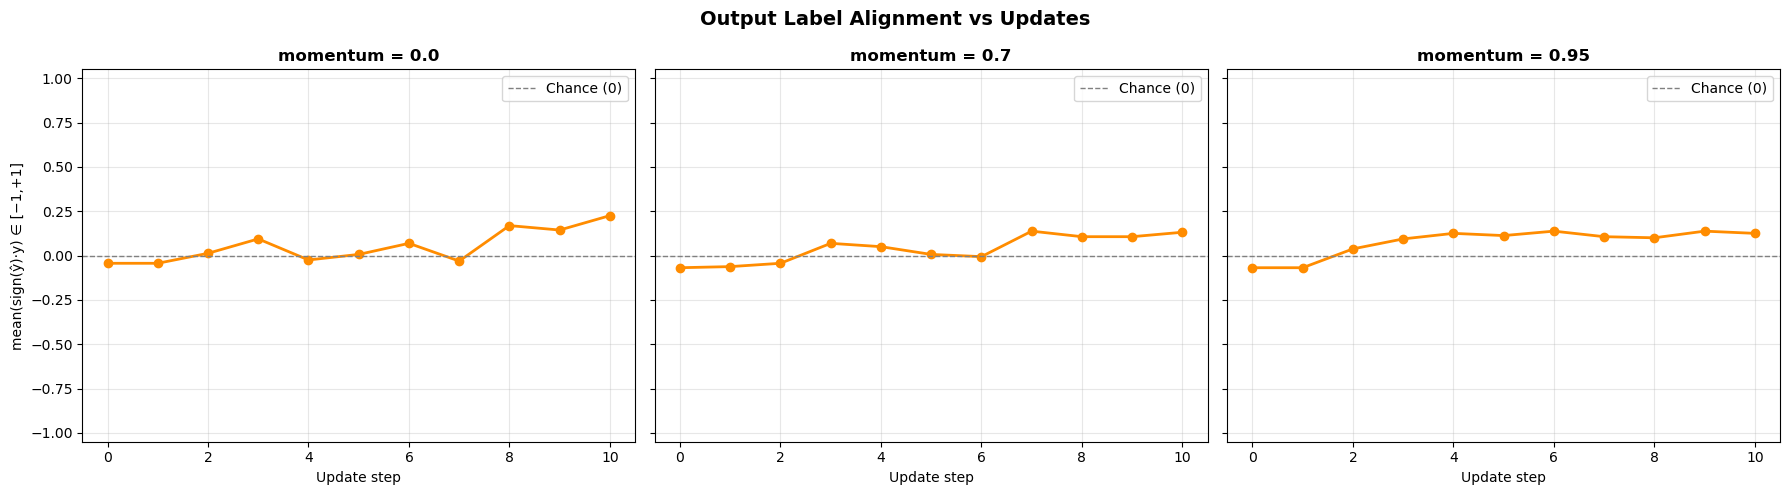

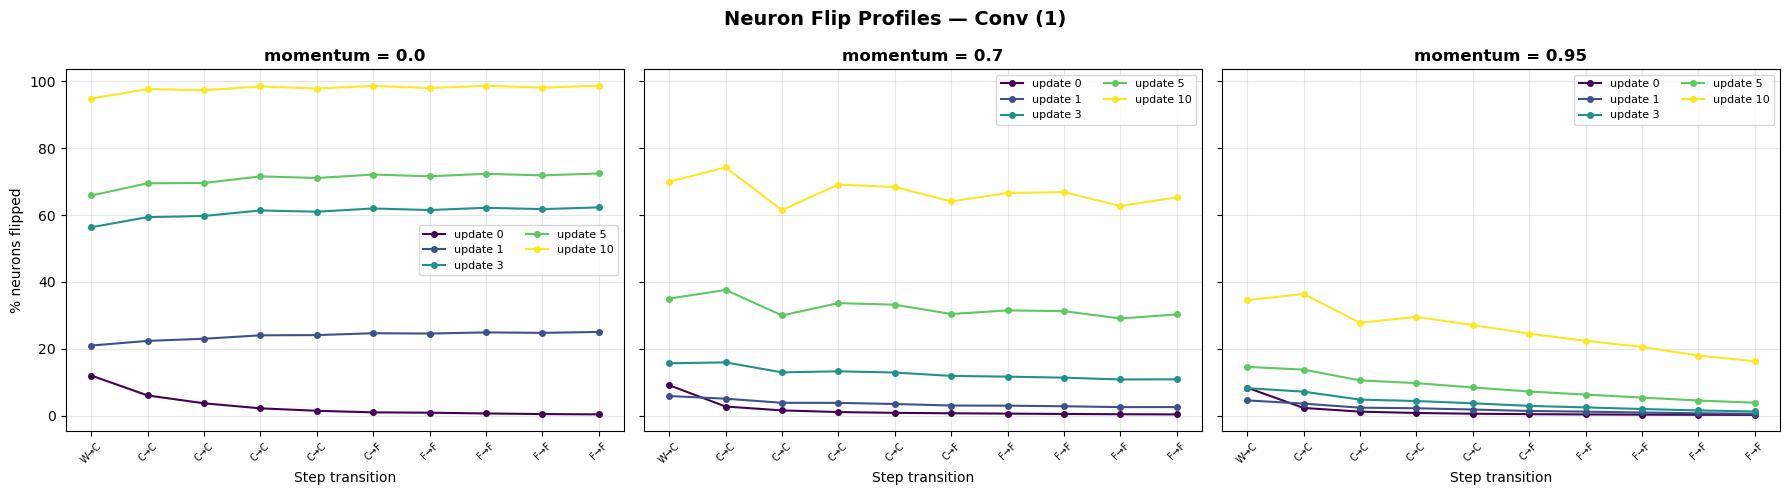

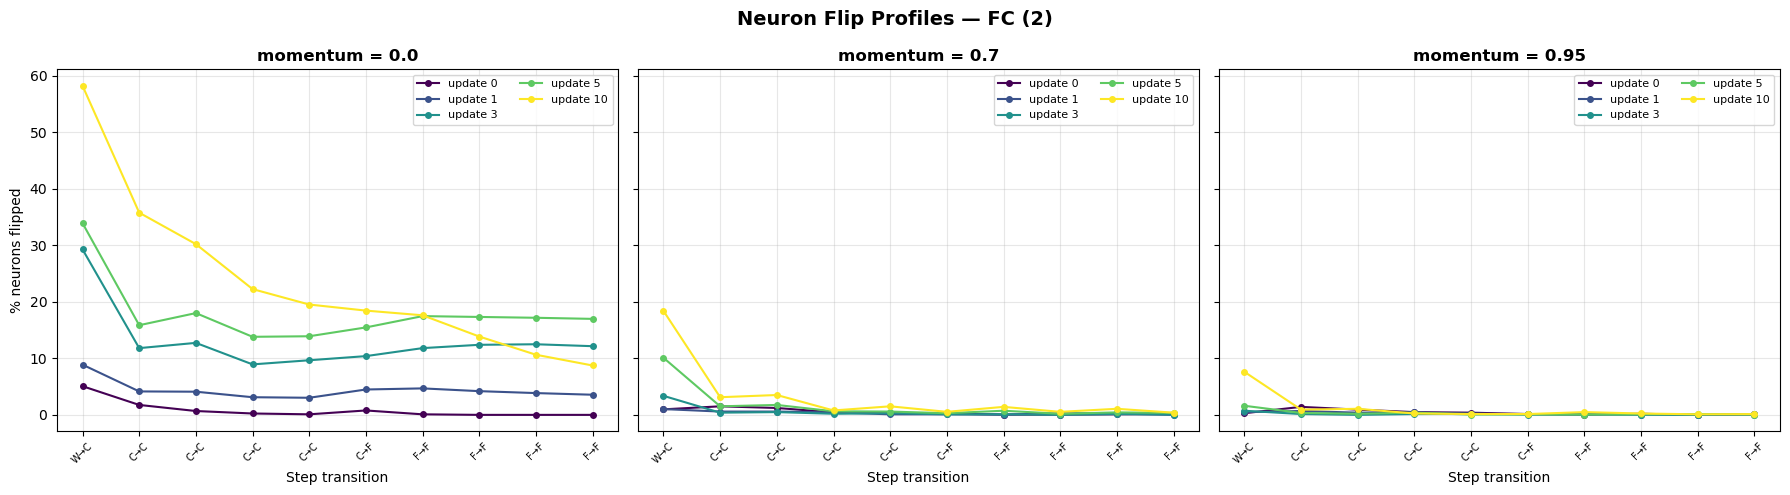

In [28]:
for mo in MOMENTUM:
    plot_cosine_matrices(all_results[mo], f"Cosine Similarity Matrices — momentum={mo}")

plot_all_summary_by_metric(all_results, MOMENTUM)
plot_flip_profiles_by_momentum(all_results, MOMENTUM)


## Observations — Momentum Sweep

### Cosine Similarity Matrices
At `momentum=0.0`, same as the no-masking baseline: checkerboard appears in Conv by update 1, deep anti-correlations by update 10. At 0.7, the pattern is delayed (visible by update 5) and weaker. At 0.95 it appears only by update 10, and FC barely develops any cross-phase structure at all.  
**→ Momentum slows phase separation but does not prevent it, unlike masking — given enough updates, the checkerboard still emerges.**

### Neuron Flips
Conv: ~98% → ~67% → ~26% across 0.0 / 0.7 / 0.95. FC: ~25% → ~3% → ~1%. Momentum suppresses FC flips almost entirely, while Conv remains moderately active even at 0.95.  
**→ Momentum stabilises FC dynamics far more effectively than Conv; the asymmetry is larger than with masking.**

### Clamped–Free Distance
Conv CF-dist: ~1.95 / ~1.27 / ~0.42. FC: ~0.7 / ~0.10 / ~0.02. Momentum kills the FC learning signal first, while Conv retains a larger signal.  
**→ At momentum=0.95, FC has essentially no contrastive signal. The coupling between layers is very unbalanced.**

### Weight Norms
$\|J_\text{conv}\|_F$ reaches ~2700 / ~1400 / ~340 at 0.0 / 0.7 / 0.95. In all cases it is **still growing** by update 10 — just more slowly.  
**→ Unlike masking, momentum does not bound weight norms. Even at 0.95, $J_\text{conv}$ is on a divergent trajectory. This is the key difference from masking.**

### W_back Overlap
`momentum=0.0`: flat ~0.05. `momentum=0.7`: gradually increases to ~0.25 by update 10. `momentum=0.95`: flat ~0.10.  
**→ momentum=0.7 is the only condition where the feedback pathway becomes progressively more effective — a positive sign for credit assignment absent in the masking experiment.**

### Free-Phase Accuracy & Output Alignment
All conditions near chance, but `momentum=0.7` shows the clearest late-stage improvement (~26–28% by update 9–10). Output alignment is slightly lower with higher momentum (~0.15 vs ~0.20).  
**→ momentum=0.7 may provide a better learning regime at the output level than either extreme.**

### Neuron Flip Profiles
`momentum=0.0`: same runaway pattern. `momentum=0.7`: large W→C disruption followed by strong within-phase convergence for FC (near-zero flips within 2 clamped steps) — the best FC phase structure observed. Conv still grows. `momentum=0.95`: FC dynamics nearly dead; Conv develops slowly.  
**→ momentum=0.7 achieves the most structured FC dynamics, but Conv at 0.7 still shows runaway growth.**

---
**Summary**

| | `0.0` | `0.7` | `0.95` |
|---|---|---|---|
| Contrastive signal (Conv CF-dist) | ~1.95 ✗ divergent | ~1.27 ⚠ large | ~0.42 ✓ moderate |
| $\|J_\text{conv}\|_F$ after 10 updates | ~2700 ✗ | ~1400 ✗ still diverging | ~340 ⚠ |
| W_back overlap trend | flat ✗ | growing ✓ | flat ✗ |
| FC phase dynamics | ✗ chaotic | ✓ best | ✗ frozen |
| Accuracy trend | noisy | ✓ best late | moderate |

**vs. masking:** momentum=0.7 has better $W_\text{back}$ alignment and cleaner FC dynamics than mask=0.3, but $J_\text{conv}$ is still diverging — masking is strictly more stable. A combination of moderate masking + moderate momentum may be optimal: masking to bound the weights, momentum to smooth FC dynamics and strengthen feedback.
